In [1]:
#!python -m spacy download es_core_news_md
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from unidecode import unidecode
import  pandas as pd
import spacy
import nltk
import re

In [2]:
data = pd.read_csv('./data/punta_cana.csv')
data['review_text'] = data['review_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
data['target'] = data['rating'].apply(lambda x: 0 if x < 4 else 1)


In [3]:
nltk.download("stopwords")
nlp = spacy.load("es_core_news_md")
stopwords_es = set(stopwords.words("spanish"))
neg_keep = {"no", "ni", "tampoco"}
stopwords_es = stopwords_es - neg_keep

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\delga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
punct_re = re.compile(r"[()\[\]{}\/\\'¿!¡?.,;:\"<>|@#$%^&*_+=~`-]")
def clean_text(texto: str, return_str: bool = False):
    doc = nlp(texto)

    tokens = []
    for t in doc:
        if t.is_space or t.is_punct or t.is_digit:
            continue
        lemma = t.lemma_.lower()
        if lemma in stopwords_es:
            continue
        clean_tok = unidecode(lemma)
        clean_tok = punct_re.sub("", clean_tok)
        if clean_tok and clean_tok.isalpha():
            tokens.append(clean_tok)

    return " ".join(tokens) if return_str else tokens
data['tokenized_text'] = data['review_text'].apply(lambda x: clean_text(x))

In [5]:
token_frequencies = data['tokenized_text'].explode()
token_frequencies = token_frequencies.value_counts().reset_index()
token_frequencies.columns = ['token', 'frequency']
token_frequencies_gt20 = token_frequencies[token_frequencies['frequency'] > 10]
vocab = token_frequencies_gt20['token'].to_list()
data['tokenized_text_without_vocab'] = data['tokenized_text'].apply(lambda tokens: [t for t in tokens if t in vocab])

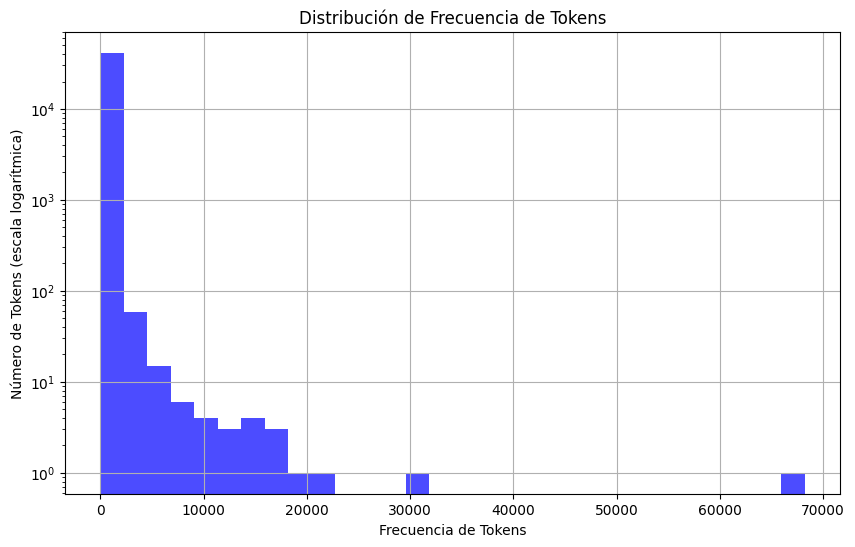

In [6]:

plt.figure(figsize=(10, 6))
plt.hist(token_frequencies['frequency'], bins=30, color='blue', alpha=0.7)
plt.yscale('log')
plt.xlabel('Frecuencia de Tokens')
plt.ylabel('Número de Tokens (escala logarítmica)')
plt.title('Distribución de Frecuencia de Tokens')
plt.grid(True)

plt.savefig('token_frequency_distribution.png')
plt.show()

In [7]:
data['bigrams'] = data['tokenized_text_without_vocab'].apply(lambda tokens: [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)])
bigrams_positive = data[data['target'] == 1]['bigrams'].explode()   
bigrams_negative = data[data['target'] == 0]['bigrams'].explode()   
bigrams_positive_freq = bigrams_positive.value_counts().reset_index()
bigrams_negative_freq = bigrams_negative.value_counts().reset_index()
bigrams_positive_freq.columns = ['token', 'frequency']
bigrams_negative_freq.columns = ['token', 'frequency']

# Filtrar por frecuencia mayor a 10
bigrams_positive_freq = bigrams_positive_freq[bigrams_positive_freq['frequency'] > 10]
bigrams_negative_freq = bigrams_negative_freq[bigrams_negative_freq['frequency'] > 10]
n = min(len(bigrams_positive_freq), len(bigrams_negative_freq))
bigrams_positive_freq = bigrams_positive_freq.nlargest(n, 'frequency')
bigrams_negative_freq = bigrams_negative_freq.nlargest(n, 'frequency')
bigrams_all = pd.concat([bigrams_positive_freq, bigrams_negative_freq], ignore_index=True)
bigrams_all = bigrams_all.sort_values('frequency', ascending=False).drop_duplicates(subset=['token'])
bigrams_all = bigrams_all.reset_index(drop=True)
bigrams = bigrams_all['token'].to_list()
data['bigrams_without_vocab'] = data['bigrams'].apply(lambda tokens: [t for t in tokens if t in bigrams])

In [8]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, token_pattern=None)
tfidf_matrix = tfidf_vectorizer.fit_transform(data['bigrams_without_vocab'])
feature_names = tfidf_vectorizer.get_feature_names_out()
x = tfidf_matrix.toarray()
y = data['target'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:,1]  
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9346159409807608

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.51      0.64       786
           1       0.94      0.99      0.96      6127

    accuracy                           0.93      6913
   macro avg       0.90      0.75      0.80      6913
weighted avg       0.93      0.93      0.93      6913


Confusion Matrix:
 [[ 399  387]
 [  65 6062]]


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
svm_model = SVC(kernel='poly', degree=3, C=1, random_state=42)
cv_scores = cross_val_score(svm_model, x, y, cv=3, scoring='f1', n_jobs=-1, verbose=1)
print(f"SVM Poligonal - f1 medio: {cv_scores.mean():.4f}, Desviación estándar: {cv_scores.std():.4f}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 83.3min finished


SVM Poligonal - Accuracy medio: 0.9406, Desviación estándar: 0.0007


In [ ]:
svm_model = SVC(kernel='poly', degree=3, C=1, random_state=42)
svm_model.fit(X_train, y_train)
y_svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_svm_pred))
print("\nSVM Classification Report:\n", classification_report(y_test, y_svm_pred))

